# Bayesian VAR (BVAR) — Expanding-Window Forecasting Pipeline

This notebook implements a **Bayesian Vector Autoregression (BVAR)** with
a Gibbs sampler and compares it to the frequentist VAR(2) already estimated.

### Background

The VAR(p) model is written in stacked form as
$$
y_t = X_t \beta + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0, \Sigma),
$$
where $y_t$ is the $n \times 1$ vector of endogenous variables,
$X_t = (I_n \otimes [1, y_{t-1}', \ldots, y_{t-p}'])$ and
$\beta = \text{vec}([b, A_1, \ldots, A_p]')$.  
Following the course notes (Chapter 5, Section 5.1), we place the conjugate priors
$$
\beta \sim \mathcal{N}(\beta_0, V_\beta), \qquad
\Sigma \sim \mathcal{IW}(\nu_0, S_0).
$$
Bayesian inference then proceeds by iterating between the two **full
conditional posterior distributions** (Gibbs sampler):
$$
\beta \mid \Sigma, y \sim \mathcal{N}(\hat{\beta}, K_\beta^{-1}),
\qquad
\Sigma \mid \beta, y \sim \mathcal{IW}\!\left(\nu_0 + T,\; S_0 + \sum_t (y_t - X_t\beta)(y_t - X_t\beta)'\right),
$$
where $K_\beta = V_\beta^{-1} + X'(I_T \otimes \Sigma^{-1})X$ and
$\hat{\beta} = K_\beta^{-1}(V_\beta^{-1}\beta_0 + X'(I_T \otimes \Sigma^{-1})y)$.  
Because the full conditionals are standard distributions, **every update is
a Gibbs step** — there is no Metropolis–Hastings rejection.

The posterior predictive distribution for $y_{T+1}$ is obtained by drawing
$$
\hat{y}_{T+1}^{(i)} = X_{T+1}\beta^{(i)} + \varepsilon^{(i)},
\qquad \varepsilon^{(i)} \sim \mathcal{N}(0, \Sigma^{(i)})
$$
for each retained MCMC draw $i$, producing a full predictive distribution
rather than a single point estimate.

---
## 0 · Imports & Data

Re-run the preprocessing exactly as before, then grab the objects that were
already created by the VAR section.

In [1]:
from preprocessing.pipeline import preprocess_all
from frequentist.models import VAR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart
from numpy.linalg import inv, cholesky
from statsmodels.tsa.vector_ar.var_model import VAR as smVAR

# ── Reproducibility ──────────────────────────────────────────────────────────
rng = np.random.default_rng(seed=6)

In [2]:
# ── Preprocess (identical to the VAR notebook) ────────────────────────────────
artifacts = preprocess_all(
    data_path="../data/complete_dataset.csv",
    date_col="date",
    start="1996-01-01",
    end="2023-11-30",
    select_cols=[
        "date",
        "global_EUI_GDP_weighted", "GPR", "cpu_index",
        "Europe Brent Spot Price FOB (Dollars per Barrel)"
    ],
    rename_map={
        "global_EUI_GDP_weighted": "eui",
        "GPR": "gpr",
        "cpu_index": "cpu",
        "Europe Brent Spot Price FOB (Dollars per Barrel)": "oil_price",
    },
    log_cols=["eui", "gpr", "cpu", "oil_price"],
    diff_cols=["eui", "gpr", "cpu", "oil_price"],
    add_event_flags=True,
    train_ratio=0.8,
    save=False,
    save_path=None,
    visualize_flags=False,
)

features_df = artifacts["features_df"]
train_df    = artifacts["train_df"]
test_df     = artifacts["test_df"]
target_col  = "log_eui"

# Endogenous variables (log levels) — same as VAR
var_endog_cols = ["log_eui", "log_gpr", "log_cpu", "log_oil_price"]

endog_train = train_df[var_endog_cols].dropna()
endog_test  = test_df[var_endog_cols]
endog_full  = pd.concat([endog_train, endog_test])

test_index = test_df.index
n_train    = len(endog_train)

print(f"Training observations : {n_train}")
print(f"Test observations     : {len(endog_test)}")
print(f"Variables             : {var_endog_cols}")


[Info] Missing values by column:
global_EUI_equally_weighted                         128
global_EUI_GDP_weighted                             128
GPR                                                 106
SHARE_GPR                                           106
N10                                                 106
GPRC_ARG                                            106
GPRC_AUS                                            106
GPRC_BEL                                            106
GPRC_BRA                                            106
GPRC_CAN                                            106
GPRC_CHE                                            106
GPRC_CHL                                            106
GPRC_CHN                                            106
GPRC_COL                                            106
GPRC_DEU                                            106
GPRC_DNK                                            106
GPRC_EGY                                            106
GPRC_ESP      

---
## Phase 1 · Setup and Initialisation

### 1.1 Dimensions and lag order

In [3]:
# ── Model dimensions ─────────────────────────────────────────────────────────
p = 2            # lag order — identical to the frequentist VAR
n = len(var_endog_cols)   # number of endogenous variables  (n = 4)
k = n * p + 1   # coefficients per equation: intercept + n*p lags  (k = 9)

# ── MCMC settings ────────────────────────────────────────────────────────────
N_draws  = 10_000   # total Gibbs draws per window
N_burnin =  2_000   # draws discarded as burn-in
N_keep   = N_draws - N_burnin   # = 8 000 draws used for forecasting

print(f"VAR({p})  |  n={n} variables  |  k={k} coefficients per equation")
print(f"MCMC: {N_draws} draws, {N_burnin} burn-in → {N_keep} retained")

VAR(2)  |  n=4 variables  |  k=9 coefficients per equation
MCMC: 10000 draws, 2000 burn-in → 8000 retained


### 1.3 Helper: build the $X$ and $y$ matrices for a VAR($p$)

For a dataset with $T$ observations and $n$ variables we build:
- $Y$ : $(T-p) \times n$ matrix of left-hand-side observations
- $X$ : $(T-p) \times (np+1)$ matrix with an intercept and $p$ lags

In [4]:
import numpy as np
from statsmodels.tsa.ar_model import AutoReg

def estimate_sigma_ar(data: np.ndarray, p: int) -> np.ndarray:
    """
    Fit a univariate AR(p) on each column of data and return the
    vector of residual standard deviations (length n).
    These are used to make the Minnesota prior scale-invariant.
    """
    n = data.shape[1]
    sigma_hat = np.empty(n)
    for i in range(n):
        res = AutoReg(data[:, i], lags=p, old_names=False).fit()
        sigma_hat[i] = np.std(res.resid)
    return sigma_hat

def build_XY(data: np.ndarray, p: int):
    """
    Build the regressor matrix X and response matrix Y for a VAR(p).

    Parameters
    ----------
    data : ndarray of shape (T, n)
        Raw time-series matrix (rows = time, columns = variables).
    p : int
        Lag order.

    Returns
    -------
    Y : ndarray (T-p, n)   — left-hand side
    X : ndarray (T-p, np+1) — right-hand side (intercept + lags)
    """
    T, n = data.shape
    rows = T - p
    X = np.ones((rows, n * p + 1))    # first column = intercept
    for lag in range(1, p + 1):
        col_start = 1 + (lag - 1) * n
        col_end   = 1 + lag * n
        X[:, col_start:col_end] = data[p - lag: T - lag, :]
    Y = data[p:, :]
    return Y, X


def get_ols_start(data: np.ndarray, p: int):
    """
    Fit a frequentist VAR(p) via OLS and return the coefficient vector
    beta_ols (shape n*k) and the residual covariance Sigma_ols (n×n).
    These serve as starting values for the Gibbs sampler.
    """
    Y, X = build_XY(data, p)
    T_eff = Y.shape[0]
    # OLS: B_hat = (X'X)^{-1} X'Y  — shape (k, n)
    B_ols   = inv(X.T @ X) @ X.T @ Y
    resid   = Y - X @ B_ols            # (T_eff, n)
    Sigma   = (resid.T @ resid) / T_eff
    beta    = B_ols.T.flatten()        # vec row-wise → length n*k
    return beta, Sigma


# Quick sanity check on initial training set
data_init = endog_train.values
beta_init, Sigma_init = get_ols_start(data_init, p)
print(f"OLS β shape : {beta_init.shape}  (n*k = {n}×{k})")
print(f"OLS Σ shape : {Sigma_init.shape}")

OLS β shape : (36,)  (n*k = 4×9)
OLS Σ shape : (4, 4)


### 1.2 Prior hyperparameters

Following the course notes (Section 5.1) we use a **diffuse / Minnesota-style
flat prior**: $\beta_0 = 0$, $V_\beta = I$, $\nu_0 = 6$, $S_0 = I$.
This encodes limited prior knowledge about the VAR coefficients while
remaining conjugate to the likelihood, so every Gibbs step stays in a
closed-form distribution.

GENERAL PRIOR

In [5]:
# ── Prior hyperparameters ────────────────────────────────────────────────────
# β ~ N(β₀, V_β)  — one β vector per equation stacked: total dim = n*k
beta0  = np.zeros(n * k)           # prior mean: no prior information
V_beta = np.eye(n * k)             # prior covariance: diffuse
V_beta_inv = np.eye(n * k)         # its inverse (trivial since V_beta = I)

# Σ ~ IW(ν₀, S₀)
nu0 = 6.0                          # degrees of freedom
S0  = np.eye(n)                    # scale matrix

print("Prior hyperparameters")
print(f"  β₀  : zero vector of length {n*k}")
print(f"  V_β : identity matrix ({n*k}×{n*k})")
print(f"  ν₀  : {nu0}")
print(f"  S₀  : identity matrix ({n}×{n})")

Prior hyperparameters
  β₀  : zero vector of length 36
  V_β : identity matrix (36×36)
  ν₀  : 6.0
  S₀  : identity matrix (4×4)


MINNESOTA PRIOR (INFORMED)

In [6]:
def build_minnesota_prior_data_informed(
    n, p, sigma_hat, beta_ols,
    lambda1=0.2, lambda2=0.5, lambda3=1.0, intercept_var=100.0
):
    """
    Minnesota prior where the prior MEAN comes from OLS on the
    initial training set, rather than the random-walk assumption.
    This is sometimes called a 'training-sample prior' or
    'data-driven Minnesota prior'.
    """
    k  = n * p + 1
    nk = n * k

    # Start from OLS estimates rather than the random-walk assumption
    beta0  = beta_ols.copy()
    v_diag = np.zeros(nk)

    for eq in range(n):
        row_start = eq * k
        v_diag[row_start] = intercept_var   # diffuse intercept

        for lag in range(1, p + 1):
            for var in range(n):
                col = row_start + 1 + (lag - 1) * n + var
                if var == eq:
                    v_diag[col] = (lambda1 / lag ** lambda3) ** 2
                else:
                    v_diag[col] = (
                        lambda1 * lambda2 / lag ** lambda3
                        * sigma_hat[eq] / sigma_hat[var]
                    ) ** 2

    V_beta_inv = np.diag(1.0 / v_diag)
    return beta0, np.diag(v_diag), V_beta_inv

# The sweet spot given your diagnostics:
# - lambda1 in [0.1, 0.2]: enough shrinkage to matter, not so tight it dominates
# - lambda2 in [0.8, 1.0]: cross-variable effects barely shrunk since oil matters
# - prior mean = OLS estimates: eliminates the random-walk bias on L1.log_eui

sigma_hat = estimate_sigma_ar(endog_train.values, p)
beta_ols, _ = get_ols_start(endog_train.values, p)

beta0_mn, V_beta_mn, V_beta_inv_mn = build_minnesota_prior_data_informed(
    n=n, p=p,
    sigma_hat=sigma_hat,
    beta_ols=beta_ols,      # <-- prior mean anchored at OLS, not random walk
    lambda1=0.05,           # moderate tightness
    lambda2=0.5,            # cross-variable effects nearly as free as own lags
    lambda3=1.0,
    intercept_var=100.0,
)

---
## Phase 2 · Expanding-Window Gibbs Sampler

### 2.1 Core Gibbs sampler

The two full conditional posterior distributions are (course notes, Ch. 5):

**Draw $\beta$:**
$$
K_\beta = V_\beta^{-1} + X'(I_T \otimes \Sigma^{-1})X, \qquad
\hat{\beta} = K_\beta^{-1}\bigl(V_\beta^{-1}\beta_0 + X'(I_T \otimes \Sigma^{-1})y\bigr)
$$
$$
\beta \mid \Sigma, y \sim \mathcal{N}(\hat{\beta},\; K_\beta^{-1})
$$

**Draw $\Sigma$:**
$$
\Sigma \mid \beta, y \sim \mathcal{IW}\!\left(
  \nu_0 + T,\;
  S_0 + \sum_{t=1}^{T}(y_t - X_t\beta)(y_t - X_t\beta)'
\right)
$$

Because both conditionals are standard distributions the Gibbs sampler
**always accepts** the proposed draw — unlike Metropolis–Hastings where
proposals can be rejected.

In [7]:
def run_gibbs(
    Y: np.ndarray,
    X: np.ndarray,
    beta0: np.ndarray,
    V_beta_inv: np.ndarray,
    nu0: float,
    S0: np.ndarray,
    N_draws: int,
    beta_start: np.ndarray,
    Sigma_start: np.ndarray,
    rng: np.random.Generator,
):
    """
    Run the Gibbs sampler for the BVAR.

    Parameters
    ----------
    Y, X       : response and regressor matrices (T_eff × n, T_eff × k)
    beta0      : prior mean  (n*k,)
    V_beta_inv : inverse prior covariance  (n*k × n*k)
    nu0, S0    : IW prior parameters
    N_draws    : total number of Gibbs iterations
    beta_start : starting β vector  (n*k,)
    Sigma_start: starting Σ matrix  (n × n)
    rng        : numpy random Generator

    Returns
    -------
    beta_draws  : ndarray (N_draws, n*k)
    Sigma_draws : ndarray (N_draws, n, n)
    """
    T_eff, n_ = Y.shape
    k_        = X.shape[1]
    nk        = n_ * k_

    beta_draws  = np.empty((N_draws, nk))
    Sigma_draws = np.empty((N_draws, n_, n_))

    # ── Initialise ───────────────────────────────────────────────────────────
    beta_curr  = beta_start.copy()
    Sigma_curr = Sigma_start.copy()

    # Pre-compute X'X (reused every iteration; only Sigma changes)
    XtX = X.T @ X          # (k, k)
    Xty = X.T @ Y          # (k, n)  —  Y = stacked responses

    for s in range(N_draws):
        # ── Step 1: draw β | Σ, y ────────────────────────────────────────────
        Sigma_inv = inv(Sigma_curr)                    # (n, n)

        # K_β = V_β^{-1} + (Σ^{-1} ⊗ X'X)  — exploiting the Kronecker structure
        # Full form: X'(I_T ⊗ Σ^{-1})X with X as (T,k), which equals
        # Σ^{-1} ⊗ X'X when each equation shares the same X.
        K_beta = V_beta_inv + np.kron(Sigma_inv, XtX)  # (nk, nk)
        K_beta_inv = inv(K_beta)

        # β̂ = K_β^{-1} (V_β^{-1} β₀ + vec(X'Y Σ^{-1}))
        # vec(X'Y Σ^{-1}) = (Σ^{-1} ⊗ X') vec(Y') = kron(Σ^{-1}, X.T) @ Y.flatten()
        rhs = V_beta_inv @ beta0 + (Xty @ Sigma_inv).T.flatten()
        beta_hat = K_beta_inv @ rhs                    # (nk,)

        # Sample β ~ N(β̂, K_β^{-1})  using Cholesky for numerical stability
        L = cholesky(K_beta_inv)
        beta_curr = beta_hat + L @ rng.standard_normal(nk)

        # ── Step 2: draw Σ | β, y ────────────────────────────────────────────
        # Reshape β from (nk,) to (n, k) then transpose to (k, n)
        B_curr = beta_curr.reshape(n_, k_).T          # (k, n)
        resid  = Y - X @ B_curr                        # (T_eff, n)
        S_star = S0 + resid.T @ resid                  # (n, n) — posterior scale

        # Sample Σ ~ IW(ν₀ + T_eff, S_star)
        Sigma_curr = invwishart.rvs(df=nu0 + T_eff, scale=S_star, random_state=rng)

        beta_draws[s]  = beta_curr
        Sigma_draws[s] = Sigma_curr

    return beta_draws, Sigma_draws


print("Gibbs sampler function defined.")

Gibbs sampler function defined.


### 2.2 Expanding-window loop

At each step $t$ we:
1. Build the training window $y_{1:t}$.
2. Run the Gibbs sampler, warm-starting from the previous window's last draw.
3. Discard the burn-in and generate 8 000 predictive draws $\hat{y}_{t+1}^{(i)}$.
4. Summarise the predictive distribution (mean + 90% credible interval).

In [8]:
# ── Storage ──────────────────────────────────────────────────────────────────
bvar_point_forecasts = []   # posterior predictive mean of log_eui
bvar_lower_bounds    = []   # 5th percentile  (90% credible interval)
bvar_upper_bounds    = []   # 95th percentile

# ── Index of log_eui in the variable list ────────────────────────────────────
eui_idx = var_endog_cols.index("log_eui")   # = 0

# ── Initialise warm-start values using OLS on the initial training set ───────
beta_warm, Sigma_warm = get_ols_start(endog_train.values, p)

print("Starting the expanding-window BVAR loop …")
print(f"  Test periods: {len(test_index)}  ({test_index[0].date()} → {test_index[-1].date()})")
print()

for step, current_date in enumerate(test_index):

    # ── 1. Slice the current training window ─────────────────────────────────
    end_idx    = n_train + step          # exclusive upper bound in endog_full
    y_train    = endog_full.iloc[:end_idx].dropna().values   # (T_curr, n)
    T_curr     = y_train.shape[0]

    Y_t, X_t = build_XY(y_train, p)     # (T_curr-p, n) and (T_curr-p, k)

    # ── 2. Run Gibbs sampler ─────────────────────────────────────────────────
    beta_draws, Sigma_draws = run_gibbs(
        Y=Y_t, X=X_t,
        beta0=beta0_mn, V_beta_inv=V_beta_inv_mn, # HERE TO CHANGE THE PRIOR
        nu0=nu0, S0=S0,
        N_draws=N_draws,
        beta_start=beta_warm,
        Sigma_start=Sigma_warm,
        rng=rng,
    )

    # ── Warm-start optimisation: save last draw for next iteration ────────────
    beta_warm  = beta_draws[-1]
    Sigma_warm = Sigma_draws[-1]

    # ── 3. Discard burn-in ───────────────────────────────────────────────────
    beta_keep  = beta_draws[N_burnin:]   # (N_keep, nk)
    Sigma_keep = Sigma_draws[N_burnin:]  # (N_keep, n, n)

    # ── 4. Build X_{t+1}: the row used to forecast one step ahead ────────────
    # X_{t+1} = [1,  y_T,  y_{T-1}, …, y_{T-p+1}]  (1 × k)
    last_obs = y_train[-p:]              # last p observations  (p, n)
    x_next   = np.concatenate(
        [[1.0]] + [last_obs[p - lag].tolist() for lag in range(1, p + 1)]
    )                                    # (k,)

    # ── 5. Generate the predictive distribution ───────────────────────────────
    step_forecasts = np.empty(N_keep)

    for i in range(N_keep):
        B_i   = beta_keep[i].reshape(n, k).T   # (k, n)
        eps_i = rng.multivariate_normal(
            mean=np.zeros(n), cov=Sigma_keep[i]
        )                                        # (n,)
        y_hat = x_next @ B_i + eps_i            # (n,)
        step_forecasts[i] = y_hat[eui_idx]      # extract log_eui

    # ── 6. Summarise and store ────────────────────────────────────────────────
    bvar_point_forecasts.append(np.mean(step_forecasts))
    bvar_lower_bounds.append(np.percentile(step_forecasts, 5))
    bvar_upper_bounds.append(np.percentile(step_forecasts, 95))

    if (step + 1) % 10 == 0 or step == 0:
        print(
            f"  [{step+1:3d}/{len(test_index)}]  {current_date.date()}  "
            f"point = {bvar_point_forecasts[-1]:.4f}  "
            f"90% CI = [{bvar_lower_bounds[-1]:.4f}, {bvar_upper_bounds[-1]:.4f}]"
        )

print("\nExpanding-window loop complete.")

Starting the expanding-window BVAR loop …
  Test periods: 67  (2018-05-01 → 2023-11-01)

  [  1/67]  2018-05-01  point = 0.0322  90% CI = [-0.8277, 0.8925]
  [ 10/67]  2019-02-01  point = 0.1808  90% CI = [-0.6709, 1.0419]
  [ 20/67]  2019-12-01  point = 0.1107  90% CI = [-0.7591, 0.9719]
  [ 30/67]  2020-10-01  point = 0.1015  90% CI = [-0.7279, 0.9477]
  [ 40/67]  2021-08-01  point = -0.0079  90% CI = [-0.8675, 0.8461]
  [ 50/67]  2022-06-01  point = 0.4112  90% CI = [-0.4266, 1.2371]
  [ 60/67]  2023-04-01  point = 0.3955  90% CI = [-0.4122, 1.1959]

Expanding-window loop complete.


In [9]:
# ── Convert lists to pandas Series aligned with the test index ───────────────
bvar_forecast_series = pd.Series(
    bvar_point_forecasts, index=test_index, name="bvar_log_eui_forecast"
)
bvar_lower_series = pd.Series(
    bvar_lower_bounds, index=test_index, name="bvar_lower_90"
)
bvar_upper_series = pd.Series(
    bvar_upper_bounds, index=test_index, name="bvar_upper_90"
)

print("BVAR forecasts (head):")
print(
    pd.DataFrame({
        "point":  bvar_forecast_series,
        "lower5": bvar_lower_series,
        "upper95": bvar_upper_series,
    }).head()
)

BVAR forecasts (head):
               point    lower5   upper95
date                                    
2018-05-01  0.032197 -0.827718  0.892496
2018-06-01  0.031148 -0.879866  0.931572
2018-07-01  0.083478 -0.782417  0.954585
2018-08-01  0.241328 -0.644585  1.109023
2018-09-01  0.147227 -0.705011  0.999890


---
## Phase 3 · Evaluation and Comparison

### 3.1 Frequentist VAR benchmark

Re-run the VAR(2) expanding-window forecasts so everything is in the same
notebook. We also capture forecast-interval bounds from the asymptotic normal
approximation implemented in `statsmodels`.

In [10]:
var_point_fcast  = []
var_lower_fcast  = []
var_upper_fcast  = []

for i, current_date in enumerate(test_index):
    end_idx     = n_train + i
    endog_win   = endog_full.iloc[:end_idx].dropna()

    var_model_i = smVAR(endog_win)
    var_res_i   = var_model_i.fit(p, trend='c', verbose=False)

    y_history   = endog_win.values[-p:]
    # forecast_interval gives the point forecast + lower/upper 90% freq. CI
    fc_obj  = var_res_i.forecast_interval(y=y_history, steps=1, alpha=0.10)
    pt      = fc_obj[0][0, eui_idx]   # point forecast
    lo      = fc_obj[1][0, eui_idx]   # lower 5%
    hi      = fc_obj[2][0, eui_idx]   # upper 95%

    var_point_fcast.append(pt)
    var_lower_fcast.append(lo)
    var_upper_fcast.append(hi)

var_forecast_series = pd.Series(
    var_point_fcast, index=test_index, name="var_log_eui_forecast"
)
var_lower_series = pd.Series(var_lower_fcast, index=test_index)
var_upper_series = pd.Series(var_upper_fcast, index=test_index)

print("Frequentist VAR(2) forecasts (head):")
print(
    pd.DataFrame({
        "point":  var_forecast_series,
        "lower5": var_lower_series,
        "upper95": var_upper_series,
    }).head()
)

C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so infe

Frequentist VAR(2) forecasts (head):
               point    lower5   upper95
date                                    
2018-05-01  0.031923 -0.843720  0.907566
2018-06-01  0.031072 -0.843046  0.905191
2018-07-01  0.083297 -0.789188  0.955783
2018-08-01  0.240623 -0.630217  1.111462
2018-09-01  0.155608 -0.713637  1.024853


C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so infe

### 3.2 Error metrics: RMSE and MAE

We compare point forecasts against the actual `log_eui` values in the test set.
- **RMSE** penalises large errors more heavily.
- **MAE** gives equal weight to all errors.

In both cases a **lower value is better**.

In [11]:
actual = test_df.loc[test_index, "log_eui"]

def rmse(actual, forecast):
    return np.sqrt(np.mean((actual - forecast) ** 2))

def mae(actual, forecast):
    return np.mean(np.abs(actual - forecast))

metrics = pd.DataFrame(
    {
        "RMSE": [
            rmse(actual, var_forecast_series),
            rmse(actual, bvar_forecast_series),
        ],
        "MAE": [
            mae(actual, var_forecast_series),
            mae(actual, bvar_forecast_series),
        ],
    },
    index=["VAR(2)", "BVAR(2)"],
)

print("Out-of-sample forecast accuracy (log_eui, test set)")
print("─" * 40)
print(metrics.to_string())
print()
winner_rmse = metrics["RMSE"].idxmin()
winner_mae  = metrics["MAE"].idxmin()
print(f"Lower RMSE : {winner_rmse}")
print(f"Lower MAE  : {winner_mae}")

Out-of-sample forecast accuracy (log_eui, test set)
────────────────────────────────────────
             RMSE       MAE
VAR(2)   0.270232  0.195330
BVAR(2)  0.266789  0.193238

Lower RMSE : BVAR(2)
Lower MAE  : BVAR(2)


### 3.3 Forecast comparison plot

The shaded bands represent **fundamentally different objects**:
- The **grey** band is the frequentist 90% confidence interval — it quantifies
  the sampling uncertainty of the *estimator* in repeated hypothetical samples.
- The **blue** band is the Bayesian 90% **credible interval** — it is a direct
  probability statement: given the observed data, there is a 90% posterior
  probability that $y_{t+1}$ falls inside this interval (see course notes,
  Section 2.4.1 and Example 2.13 for the interpretation of credible intervals
  versus frequentist confidence intervals).

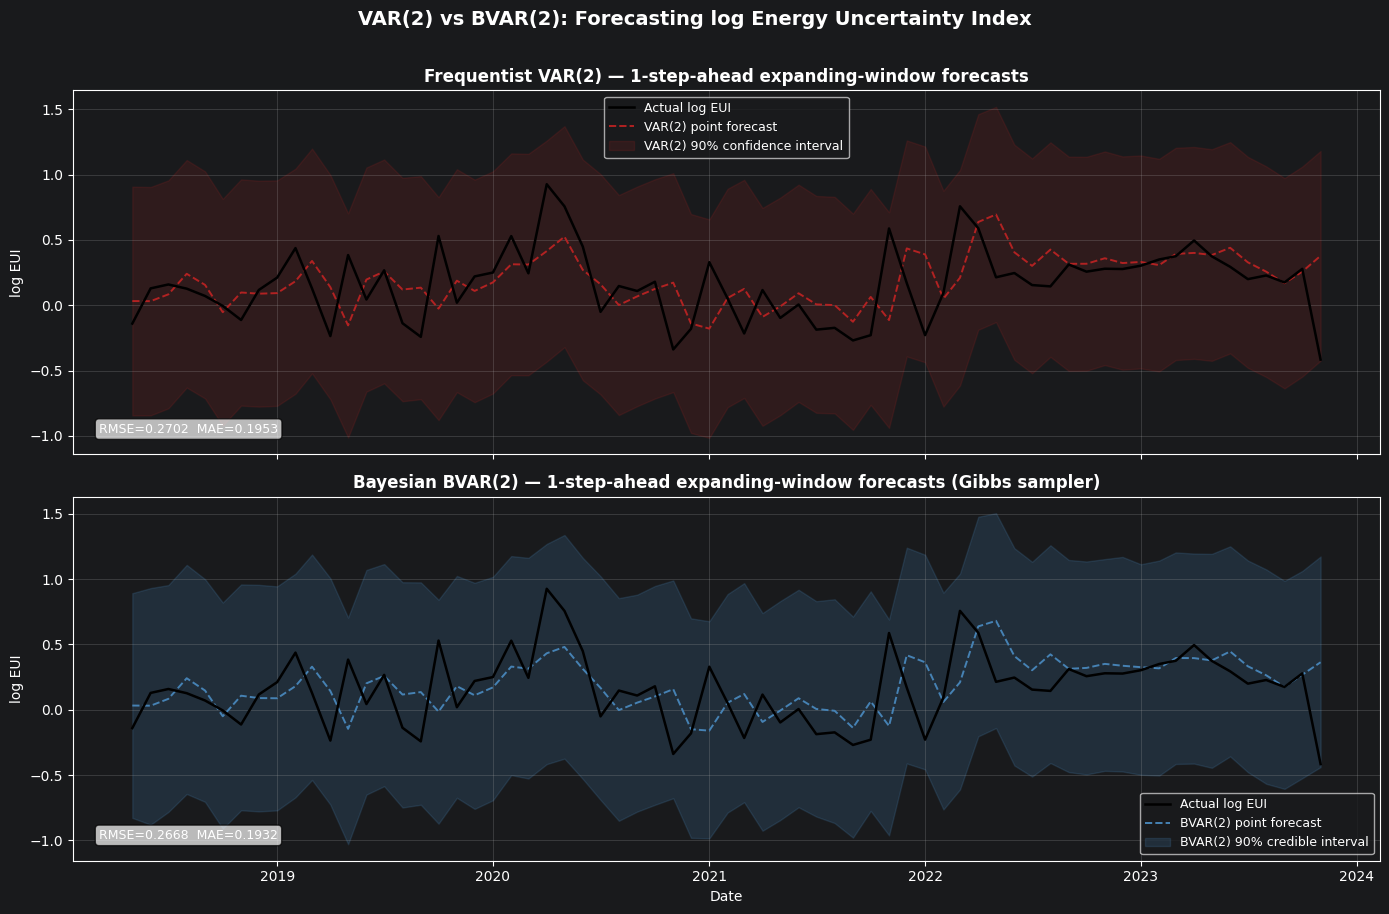

Figure saved to var_vs_bvar_forecast.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ── Top panel: Frequentist VAR ────────────────────────────────────────────────
ax = axes[0]
ax.plot(actual.index, actual.values, color="black", lw=1.8,
        label="Actual log EUI", zorder=5)
ax.plot(var_forecast_series.index, var_forecast_series.values,
        color="firebrick", lw=1.4, ls="--", label="VAR(2) point forecast")
ax.fill_between(
    var_lower_series.index,
    var_lower_series.values,
    var_upper_series.values,
    color="firebrick", alpha=0.15, label="VAR(2) 90% confidence interval"
)
ax.set_title(
    "Frequentist VAR(2) — 1-step-ahead expanding-window forecasts",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("log EUI")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
rmse_var = rmse(actual, var_forecast_series)
mae_var  = mae(actual, var_forecast_series)
ax.text(0.02, 0.06,
        f"RMSE={rmse_var:.4f}  MAE={mae_var:.4f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

# ── Bottom panel: Bayesian BVAR ───────────────────────────────────────────────
ax = axes[1]
ax.plot(actual.index, actual.values, color="black", lw=1.8,
        label="Actual log EUI", zorder=5)
ax.plot(bvar_forecast_series.index, bvar_forecast_series.values,
        color="steelblue", lw=1.4, ls="--", label="BVAR(2) point forecast")
ax.fill_between(
    bvar_lower_series.index,
    bvar_lower_series.values,
    bvar_upper_series.values,
    color="steelblue", alpha=0.20, label="BVAR(2) 90% credible interval"
)
ax.set_title(
    "Bayesian BVAR(2) — 1-step-ahead expanding-window forecasts (Gibbs sampler)",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("log EUI")
ax.set_xlabel("Date")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
rmse_bvar = rmse(actual, bvar_forecast_series)
mae_bvar  = mae(actual, bvar_forecast_series)
ax.text(0.02, 0.06,
        f"RMSE={rmse_bvar:.4f}  MAE={mae_bvar:.4f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

fig.suptitle(
    "VAR(2) vs BVAR(2): Forecasting log Energy Uncertainty Index",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("../bayesian/plots/var_vs_bvar_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to var_vs_bvar_forecast.png")

### 3.4 Uncertainty width over time

Plotting the width of both intervals makes it easy to see whether the Bayesian
model shrinks or widens uncertainty relative to the frequentist approach,
especially during periods of high volatility (e.g. COVID-19, energy crises).

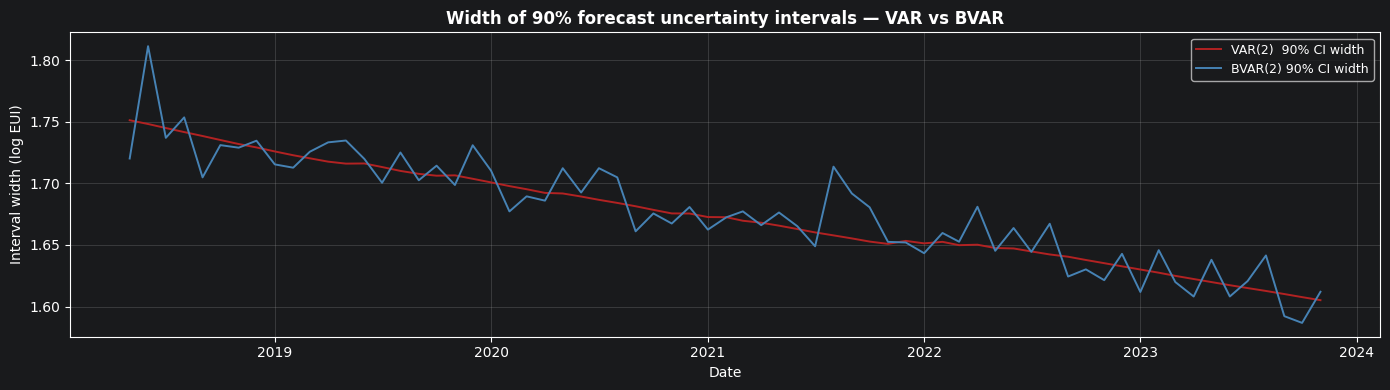

Mean VAR  CI width : 1.6747
Mean BVAR CI width : 1.6780


In [13]:
var_width  = var_upper_series  - var_lower_series
bvar_width = bvar_upper_series - bvar_lower_series

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(var_width.index,  var_width.values,
        color="firebrick",  lw=1.4, label="VAR(2)  90% CI width")
ax.plot(bvar_width.index, bvar_width.values,
        color="steelblue", lw=1.4, label="BVAR(2) 90% CI width")
ax.set_title(
    "Width of 90% forecast uncertainty intervals — VAR vs BVAR",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("Interval width (log EUI)")
ax.set_xlabel("Date")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../bayesian/plots/interval_width_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Mean VAR  CI width : {var_width.mean():.4f}")
print(f"Mean BVAR CI width : {bvar_width.mean():.4f}")

---
## Summary

| | VAR(2) | BVAR(2) |
|---|---|---|
| Estimation | OLS (Maximum Likelihood) | Gibbs sampler (MCMC) |
| Uncertainty quantification | Frequentist 90% CI (asymptotic normal) | Bayesian 90% credible interval (posterior predictive) |
| Interval interpretation | Covers true value in 90% of *repeated* experiments | 90% *posterior probability* that $y_{t+1}$ lies inside |
| Prior | None | $\beta \sim \mathcal{N}(0,I)$, $\Sigma \sim \mathcal{IW}(6, I)$ |
| Warm-starting | N/A | Yes — last Gibbs draw used as next window's start |

**Key takeaway from the course notes (Section 1.4):** the Bayesian posterior
distribution *is* the full description of our uncertainty about the parameters
and future values after seeing the data. The credible interval therefore has a
direct probability interpretation that the frequentist confidence interval does
not — as demonstrated in Example 2.13 of the course notes.

TEST TO UNDERSTAND HOW MUCH THE PRIOR IS AFFECTING THE (WRONG) RESULT

In [14]:
# Compare OLS coefficients vs BVAR posterior means
beta_ols, _ = get_ols_start(endog_train.values, p)
beta_posterior_mean = beta_keep.mean(axis=0)   # from your last Gibbs run

labels = (
    ["intercept"] +
    [f"L{lag}.{col}" for lag in range(1, p+1) for col in var_endog_cols]
)

comparison = pd.DataFrame({
    "OLS"           : beta_ols.reshape(n, k)[0],    # equation for log_eui
    "BVAR_posterior": beta_posterior_mean.reshape(n, k)[0],
    "Prior_mean"    : beta0_mn.reshape(n, k)[0],
}, index=labels)

print("Equation: log_eui")
print(comparison.round(4))

Equation: log_eui
                     OLS  BVAR_posterior  Prior_mean
intercept        -1.5748         -1.5091     -1.5748
L1.log_eui        0.4184          0.4180      0.4184
L1.log_gpr        0.1928          0.1881      0.1928
L1.log_cpu        0.1782          0.1789      0.1782
L1.log_oil_price -0.1825         -0.1910     -0.1825
L2.log_eui        0.2530          0.2524      0.2530
L2.log_gpr       -0.0717         -0.0741     -0.0717
L2.log_cpu       -0.0984         -0.0975     -0.0984
L2.log_oil_price  0.3437          0.3408      0.3437


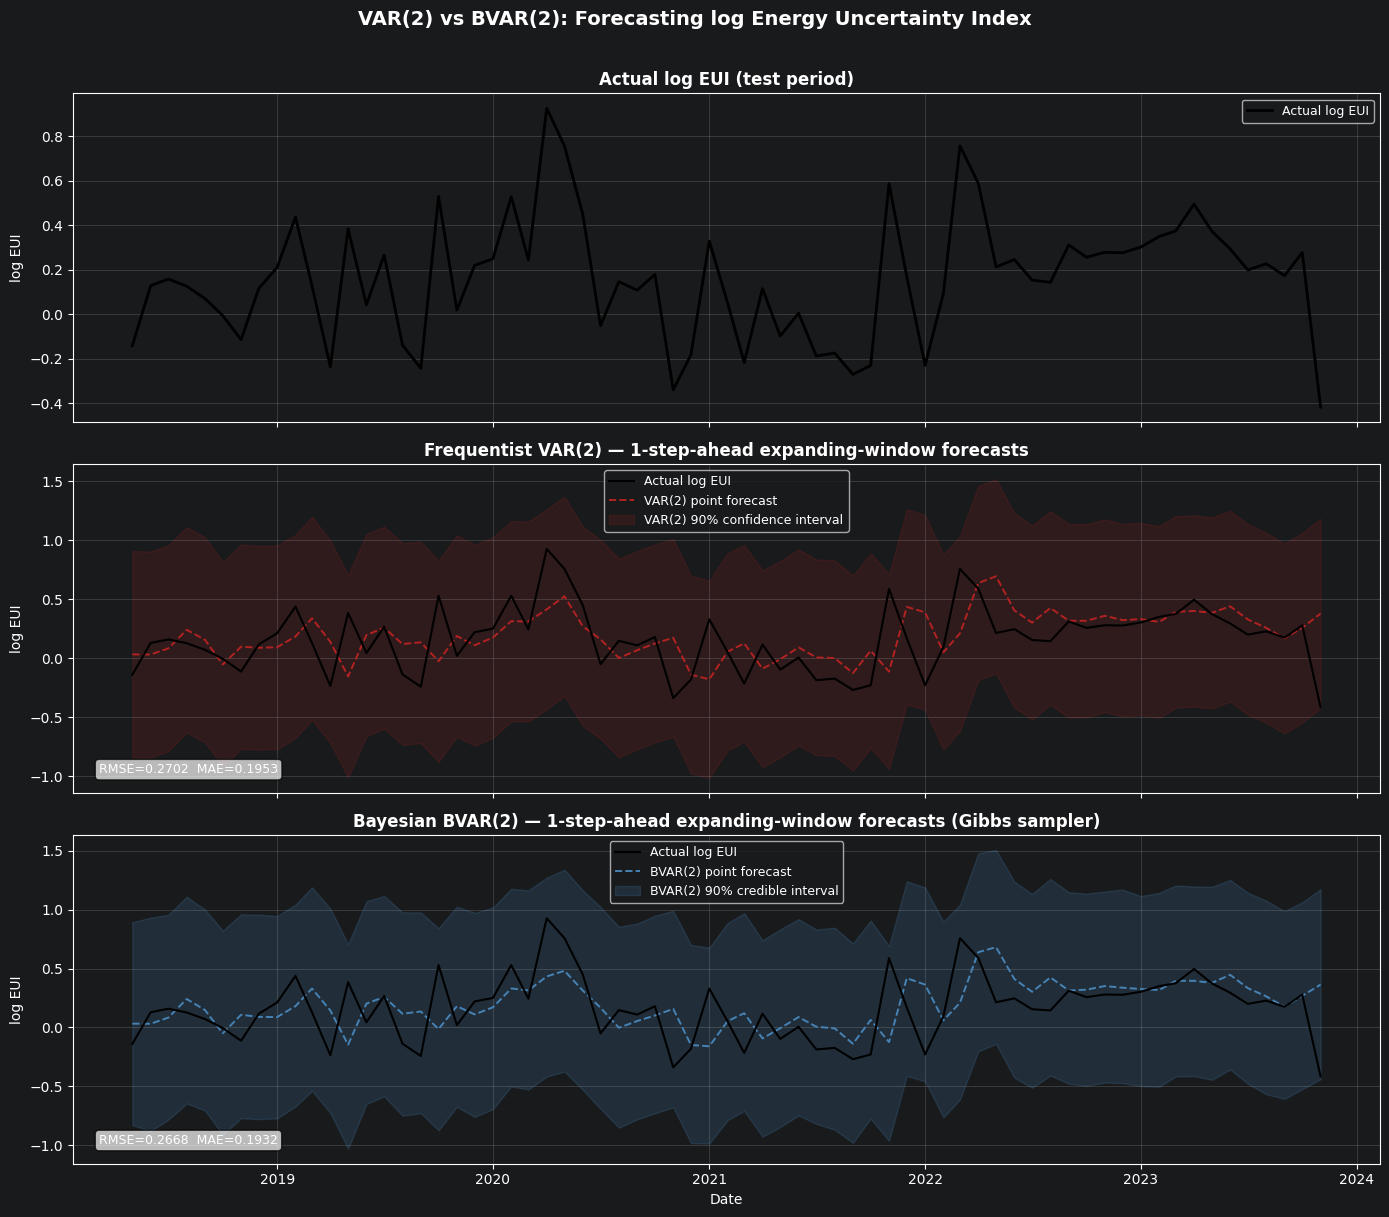

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ── Panel 1: Actual values only ───────────────────────────────────────────────
ax = axes[0]
ax.plot(actual.index, actual.values,
        color="black", lw=2.0, label="Actual log EUI")
ax.set_title("Actual log EUI (test period)", fontsize=12, fontweight="bold")
ax.set_ylabel("log EUI")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 2: Frequentist VAR ──────────────────────────────────────────────────
ax = axes[1]
ax.plot(actual.index, actual.values,
        color="black", lw=1.5, label="Actual log EUI", zorder=5)
ax.plot(var_forecast_series.index, var_forecast_series.values,
        color="firebrick", lw=1.4, ls="--", label="VAR(2) point forecast")
ax.fill_between(
    var_lower_series.index,
    var_lower_series.values,
    var_upper_series.values,
    color="firebrick", alpha=0.15,
    label="VAR(2) 90% confidence interval"
)
ax.set_title(
    "Frequentist VAR(2) — 1-step-ahead expanding-window forecasts",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("log EUI")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
rmse_var = rmse(actual, var_forecast_series)
mae_var  = mae(actual, var_forecast_series)
ax.text(0.02, 0.06, f"RMSE={rmse_var:.4f}  MAE={mae_var:.4f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

# ── Panel 3: Bayesian BVAR ────────────────────────────────────────────────────
ax = axes[2]
ax.plot(actual.index, actual.values,
        color="black", lw=1.5, label="Actual log EUI", zorder=5)
ax.plot(bvar_forecast_series.index, bvar_forecast_series.values,
        color="steelblue", lw=1.4, ls="--", label="BVAR(2) point forecast")
ax.fill_between(
    bvar_lower_series.index,
    bvar_lower_series.values,
    bvar_upper_series.values,
    color="steelblue", alpha=0.20,
    label="BVAR(2) 90% credible interval"
)
ax.set_title(
    "Bayesian BVAR(2) — 1-step-ahead expanding-window forecasts (Gibbs sampler)",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("log EUI")
ax.set_xlabel("Date")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
rmse_bvar = rmse(actual, bvar_forecast_series)
mae_bvar  = mae(actual, bvar_forecast_series)
ax.text(0.02, 0.06, f"RMSE={rmse_bvar:.4f}  MAE={mae_bvar:.4f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

fig.suptitle(
    "VAR(2) vs BVAR(2): Forecasting log Energy Uncertainty Index",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("var_vs_bvar_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

TENTATIVE GRID SEARCH

In [16]:
from itertools import product

def log_marginal_likelihood(Y, X, beta0, V_beta_inv, nu0, S0):
    """
    Closed-form log marginal likelihood for the BVAR.
    Derived by integrating out beta and Sigma analytically.
    Used to select hyperparameters without running MCMC.
    """
    T, n = Y.shape
    k    = X.shape[1]
    nk   = n * k

    K_beta     = V_beta_inv + np.kron(inv(S0 / nu0), X.T @ X)
    K_beta_inv = inv(K_beta)
    beta_hat   = K_beta_inv @ (V_beta_inv @ beta0 +
                  (X.T @ Y @ inv(S0 / nu0)).T.flatten())

    B_hat  = beta_hat.reshape(n, k).T
    resid  = Y - X @ B_hat
    S_star = S0 + resid.T @ resid

    # Log marginal likelihood (up to constants)
    lml = (
        - 0.5 * T * n * np.log(np.pi)
        + 0.5 * np.linalg.slogdet(V_beta_inv)[1]
        - 0.5 * np.linalg.slogdet(K_beta)[1]
        + 0.5 * nu0 * np.linalg.slogdet(S0)[1]
        - 0.5 * (nu0 + T) * np.linalg.slogdet(S_star)[1]
    )
    return lml


# ── Grid search ───────────────────────────────────────────────────────────────
lambda1_grid = [0.0001, 0.025, 0.04, 0.05, 0.1, 0.2, 0.3, 0.5]
lambda2_grid = [0.001, 0.1, 0.3, 0.4, 0.5, 0.8, 1.0]

# Use initial training data for the search
Y_val, X_val = build_XY(endog_train.values, p)
sigma_hat    = estimate_sigma_ar(endog_train.values, p)
beta_ols, _  = get_ols_start(endog_train.values, p)

results = []
for l1, l2 in product(lambda1_grid, lambda2_grid):
    beta0_g, V_beta_g, V_beta_inv_g = build_minnesota_prior_data_informed(
        n=n, p=p, sigma_hat=sigma_hat, beta_ols=beta_ols,
        lambda1=l1, lambda2=l2,
    )
    lml = log_marginal_likelihood(
        Y_val, X_val, beta0_g, V_beta_inv_g, nu0, S0
    )
    results.append({"lambda1": l1, "lambda2": l2, "log_ML": lml})

results_df = pd.DataFrame(results).sort_values("log_ML", ascending=False)
print("Top hyperparameter combinations by log marginal likelihood:")
print(results_df.head(10).to_string(index=False))

best = results_df.iloc[0]
print(f"\nBest: lambda1={best.lambda1}, lambda2={best.lambda2}")

Top hyperparameter combinations by log marginal likelihood:
 lambda1  lambda2       log_ML
  0.0001    0.001 -2173.234514
  0.0001    0.100 -2173.234517
  0.0001    0.300 -2173.234538
  0.0001    0.400 -2173.234557
  0.0001    0.500 -2173.234581
  0.0001    0.800 -2173.234686
  0.0001    1.000 -2173.234783
  0.0250    0.001 -2173.922737
  0.0250    0.100 -2174.071138
  0.0400    0.001 -2174.668103

Best: lambda1=0.0001, lambda2=0.001
